# Reinforcement Learning Project : N7Craft
# Training a Minecraft Jump Agent with Mineflayer & RL  
**A Gym-style Env, PPO Training Loop, and Evaluation on Custom Jump Maps**  
Briefly outline the goal of this notebook and the high-level flow:  
- Connect Mineflayer bot to a custom jump map server  
- Wrap it in a Gym environment  
- Train an RL agent (e.g. PPO)  
- Evaluate performance  

## ⚙️ Environment Setup & Imports
Launch the Minecraft Server (version 1.19.4 if you want to connect to it as a player)

In [1]:
import subprocess

# Start in background, no console output
subprocess.Popen(
    ['java', '-Xms1G', '-Xmx2G', '-jar', 'paper-1.19.4-550.jar'],
    cwd='minecraft-server',
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT
)

<Popen: returncode: None args: ['java', '-Xms1G', '-Xmx2G', '-jar', 'paper-1...>

Install and import all required libraries:
1. `pip install gym mineflayer vec3 stable-baselines3 torch matplotlib`  
2. Import Python modules for Gym, Mineflayer, NumPy, etc.  

In [2]:
# Use `n` to install nodejs 18, if it's not already installed:
#!curl -fsSL https://raw.githubusercontent.com/tj/n/master/bin/n | bash -s lts > /dev/null
# Now write the Node.js and Python version to the console
!node --version
!python --version

v22.13.1
Python 3.13.1


In [3]:
 !pip install javascript

In [4]:
!pip install gym vec3 javascript stable-baselines3 torch matplotlib

### Test imports

In [5]:
from javascript import require, On, Once, AsyncTask, once, off
import time, math, os
import numpy as np
import gymnasium as gym
from gymnasium import spaces

[JSE] (node:21372) [DEP0040] DeprecationWarning: The `punycode` module is deprecated. Please use a userland alternative instead.

[JSE] (Use `node --trace-deprecation ...` to show where the warning was created)

AggregateError [ECONNREFUSED]: 

    at internalConnectMultiple (node:net:1139:18)

    at afterConnectMultiple (node:net:1712:7) {

  code: 'ECONNREFUSED',

  [errors]: [

    Error: connect ECONNREFUSED ::1:25565

        at createConnectionError (node:net:1675:14)

        at afterConnectMultiple (node:net:1705:16) {

      errno: -4078,

      code: 'ECONNREFUSED',

      syscall: 'connect',

      address: '::1',

      port: 25565

    },

    Error: connect ECONNREFUSED 127.0.0.1:25565

        at createConnectionError (node:net:1675:14)

        at afterConnectMultiple (node:net:1705:16) {

      errno: -4078,

      code: 'ECONNREFUSED',

      syscall: 'connect',

      address: '127.0.0.1',

      port: 25565

    }

  ]

}

AggregateError [ECONNREFUSED]: 

    at in

Exception in thread Thread-13 (loop):
Traceback (most recent call last):
  File "C:\Users\coren\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1041, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\coren\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "C:\Users\coren\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 992, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\coren\AppData\Local\Programs\Python\Python313\Lib\site-packages\javascript\events.py", line 184, in loop
    barrier.wait()
    ~~~~~~~~~~~~^^
  File "C:\Users\coren\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 729, in wait
    self._wait(timeout)
    ~~~~~~~~~~^^^^^^^^^
  File "C:\Users\coren\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 767,

## 🤖 Bot Connection Helper  
Define a utility function to spawn and login the Mineflayer bot:  
- Explain that this handles network connection and event waiting  


We import Mineflayer & Vec3 (Node.js libs exposed via `javascript` package)

In [6]:
mineflayer = require('mineflayer')
Vec3 = require('vec3').Vec3

We define a function to spawn and login the Agent to the server in localhost.

In [7]:
def create_bot(host='localhost', port=25565, username="N7JumpingBot"):
    """Spawn Mineflayer bot and wait for login event."""
    bot = mineflayer.createBot({
        'host': host,
        'port': port,
        'username': username,
        'hideErrors': False
    })
    once(bot, 'login')
    print(f'🟢 Logged in as {username}')
    return bot


## 🌍 Environment definition
Define the environment parameters

In [8]:
# === Minecraft Jump RL Environment Core (Reward, Done, Teleport/Respawn) ===

# Names for special blocks from infos.txt
START_BLOCK_NAME = "iron_block"         # Iron block (start)
PATH_BLOCK_NAME = "stone"               # Stone (path)
CHECKPOINT_BLOCK_NAME = "gold_block"    # Gold block (checkpoint)
FINISH_BLOCK_NAME = "diamond_block"     # Diamond block (finish)
DEATH_BLOCK_NAME = "obsidian"           # Obsidian (death)

# Example jump spawn positions (update these for your map as needed)
JUMP_SPAWNS = [
    (8, -55, 12),   # Jump 1
    (-607, 6, -1341)   # Jump 2
]

FINISH_BLOCK_COORDS = [
    (8,-55,-13), # Jump 1
    (8,-55,-13) # Jump 2
]

Jump1 = {
    "start": (8, -55, 12),
    "finish": (8,-55,-13),
}
Jump2 = {
    "start": (8,-55,-13),
    "finish": (8, -55, 12),
}

JUMPS = [Jump1, Jump2]

## Actions definition

In [9]:
ACTION_NAMES = [
    "forward", "back", "left", "right", "jump", "sprint", "turn_left", "turn_right"
]


## 🌍 Gym-Style Environment Class  
Wrap the Mineflayer bot as a Gym `Env`:  
- Describe observation_space (9×6 block matrix)  
- Describe action_space (MultiBinary 6 for movement controls)  
- List the methods you’ll implement: `__init__`, `get_visible_blocks`, `reset`, `step`, `_compute_reward`, `_check_done`, `close`  

We create the bot once only.

In [10]:
import time
import concurrent.futures

def wait_for_bot_connection(host='localhost', port=25565, username='N7JumpingBot', retry_interval=2, connect_timeout=10):
    """
    Tries to connect the Mineflayer bot repeatedly until success (with a timeout).
    Returns the connected bot object.
    """
    c = 0
    while True:
        try:
            c += 1
            print(f"Attempt {c}: Connecting...")
            with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
                future = executor.submit(create_bot, host=host, port=port, username=username)
                bot = future.result(timeout=connect_timeout)
            print("🟢 Bot connected successfully!")
            return bot
        except concurrent.futures.TimeoutError:
            print(f"❌ Bot connection timed out after {connect_timeout}s.")
            print(f"Retrying in {retry_interval} seconds...")
        except Exception as e:
            print(f"❌ Bot connection failed: {e}")
            print(f"Retrying in {retry_interval} seconds...")
        time.sleep(retry_interval)

# Usage:
bot = wait_for_bot_connection(host='localhost', port=25565, username='N7JumpingBot', retry_interval=2, connect_timeout=10)


Attempt 1: Connecting...
❌ Bot connection failed: ('once', 'AggregateError [ECONNREFUSED]: \n    at internalConnectMultiple (node:net:1139:18)\n    at afterConnectMultiple (node:net:1712:7)')
Retrying in 2 seconds...
Attempt 2: Connecting...
❌ Bot connection failed: ('once', 'AggregateError [ECONNREFUSED]: \n    at internalConnectMultiple (node:net:1139:18)\n    at afterConnectMultiple (node:net:1712:7)')
Retrying in 2 seconds...
Attempt 3: Connecting...
❌ Bot connection failed: ('once', 'AggregateError [ECONNREFUSED]: \n    at internalConnectMultiple (node:net:1139:18)\n    at afterConnectMultiple (node:net:1712:7)')
Retrying in 2 seconds...
Attempt 4: Connecting...
❌ Bot connection failed: ('once', 'AggregateError [ECONNREFUSED]: \n    at internalConnectMultiple (node:net:1139:18)\n    at afterConnectMultiple (node:net:1712:7)')
Retrying in 2 seconds...
Attempt 5: Connecting...
❌ Bot connection failed: ('once', 'AggregateError [ECONNREFUSED]: \n    at internalConnectMultiple (node:ne

In [11]:
import math

def agent_on_block_name(bot, block_name):
    pos = bot.entity.position
    y = math.floor(pos.y - 0.1)
    for dx in [-0.3, 0.3]:
        for dz in [-0.3, 0.3]:
            x = math.floor(pos.x + dx)
            z = math.floor(pos.z + dz)
            block = bot.blockAt(Vec3(x, y, z))
            if block and block.name == block_name:
                return True
    return False


class MinecraftRL(gym.Env):
    """
    Action space (MultiBinary(8)):
        0: Move forward    --> bot.setControlState('forward', bool(action[0]))
        1: Move back       --> bot.setControlState('back', bool(action[1]))
        2: Strafe left     --> bot.setControlState('left', bool(action[2]))
        3: Strafe right    --> bot.setControlState('right', bool(action[3]))
        4: Jump            --> bot.setControlState('jump', bool(action[4]))
        5: Sprint          --> bot.setControlState('sprint', bool(action[5]))
        6: Turn left       --> bot.entity.yaw -= self.turn_delta if action[6]
        7: Turn right      --> bot.entity.yaw += self.turn_delta if action[7]
    """
    metadata = {'render.modes': ['human']}
    
    def __init__(self, host='localhost', port=25565, turn_delta=0.15, jump_id=0):
        super().__init__()
        self.bot = bot  # Reference the global bot
        self.jump = JUMPS[jump_id]
        self.observation_space = spaces.Box(low=0, high=4096, shape=(9,6), dtype=np.int32)
        self.action_space = spaces.MultiBinary(8)
        self.turn_delta = turn_delta
        self.spawn = JUMP_SPAWNS[jump_id]
        self.finish_block_name = FINISH_BLOCK_NAME
        self.death_block_name = DEATH_BLOCK_NAME
        self.last_distance_to_goal = None

    def teleport_to_start(self):
        x, y, z = self.jump["start"]
        success = False
        attempts = 0
        while not success and attempts < 3:
            try:
                self.bot.chat(f"/tp {int(x)} {int(y)} {int(z)}")
                # You may want to check bot.entity.position after a delay!
                #time.sleep(1)  # Wait for teleport to process
                success = True
            except Exception as e:
                print(f"Teleport attempt {attempts+1} failed: {e}")
                attempts += 1
                time.sleep(0.2)
        if not success:
            print("Teleport to start failed after 3 attempts.")
    
    def get_visible_blocks(self):
        """
        Returns (9x6) matrix of block.type in front of the agent.
        If any error occurs, returns zeros.
        """
        try:
            yaw = self.bot.entity.yaw
            px, py, pz = (self.bot.entity.position.x,
                          self.bot.entity.position.y,
                          self.bot.entity.position.z)
            vis = np.zeros((9, 6), dtype=np.int32)
            for d in range(1, 7):
                dx, dz = -math.sin(yaw), math.cos(yaw)
                bx = int(round(px + dx * d))
                bz = int(round(pz + dz * d))
                for i, h in enumerate(range(-4, 5)):
                    by = int(math.floor(py + h))
                    block = self.bot.blockAt(Vec3(bx, by, bz))
                    vis[i, d - 1] = block.type if block else 0
            return vis
        except Exception as e:
            print(f"get_visible_blocks() failed: {e}")
            # Fallback: zeros
            return np.zeros(self.observation_space.shape, dtype=self.observation_space.dtype)


    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.teleport_to_start()
        obs = self.get_visible_blocks()
        if obs is None:
            # Fallback: safe value
            obs = np.zeros(self.observation_space.shape, dtype=self.observation_space.dtype)
        self.last_distance_to_goal = self.distance_to_finish()
        return obs, {}

    def distance_to_finish(self):
        pos = self.bot.entity.position
        fx, fy, fz = self.jump["finish"]
        return ((pos.x - fx)**2 + (pos.y - fy)**2 + (pos.z - fz)**2)**0.5

    def step(self, action):
        # Movement controls
        self.bot.setControlState('forward', bool(action[0]))
        self.bot.setControlState('back', bool(action[1]))
        self.bot.setControlState('left', bool(action[2]))
        self.bot.setControlState('right', bool(action[3]))
        self.bot.setControlState('sprint', bool(action[5]))
    
        # Single jump pulse
        if action[4]:
            self.bot.setControlState('jump', True)
            time.sleep(0.1)
            self.bot.setControlState('jump', False)
    
        # Turning
        if action[6]:
            self.bot.entity.yaw -= self.turn_delta
        if action[7]:
            self.bot.entity.yaw += self.turn_delta
    
        time.sleep(0.2)  # For the rest of the move to process
    
        obs = self.get_visible_blocks()
        reward, done = self._compute_reward_done(obs)
        info = {}
    
        terminated = done
        truncated = False
    
        return obs, reward, terminated, truncated, info

    def _compute_reward_done(self, obs):
        # Reward and done logic based on agent's position and blocks
        if agent_on_block_name(self.bot, self.death_block_name):
            reward = -100
            done = True
        elif agent_on_block_name(self.bot, self.finish_block_name):
            reward = +100
            done = True

        else:
            dist = self.distance_to_finish()
            if self.last_distance_to_goal is not None and dist < self.last_distance_to_goal:
                reward = +1
            else:
                reward = -1
            self.last_distance_to_goal = dist
            done = False
        return reward, done


    def close(self):
        self.bot.quit()

## 🔍 Observation Utility Functions  
Break out any helper functions used inside your Env, such as:  
- Converting world coordinates to agent-relative indices  
- Sampling direction vectors from yaw  

In [12]:
from math import sin, cos, floor

def world_to_local(px, py, pz, yaw, depth, height_off):
    """
    Convert a (depth, height) offset in front of the agent into world coordinates (Vec3).
    - px, py, pz: agent position
    - yaw: agent's rotation in radians
    - depth: how far forward from the agent (in blocks)
    - height_off: vertical offset (in blocks)
    Returns: Vec3 (int x, y, z)
    """
    dx, dz = -sin(yaw), cos(yaw)
    x = int(round(px + dx * depth))
    y = int(floor(py + height_off))
    z = int(round(pz + dz * depth))
    return Vec3(x, y, z)

def get_direction_vector(yaw):
    """
    Returns the unit vector (dx, dz) for the agent's facing direction (yaw in radians).
    """
    return (-sin(yaw), cos(yaw))


## 🎯 Reward & Done Logic  
Outline your reward shaping and terminal conditions:  
- Progress reward (e.g. moving closer to goal)  
- Penalty for falling or exceeding time  
- Done flag when finish line reached or failure  


In [13]:
def compute_progress_reward(prev_vis, curr_vis, goal_block_name=FINISH_BLOCK_NAME):
    """
    Reward shaping: +1 for each additional goal block visible compared to previous observation.
    prev_vis and curr_vis are 2D arrays of block names (str).
    """
    return float(np.sum(curr_vis == goal_block_name) - np.sum(prev_vis == goal_block_name))

def check_fall_done(bot, death_block_name=DEATH_BLOCK_NAME, y_min=-100):
    """
    Checks if the agent has 'fallen':
      - Option 1: if standing on the death block (by name, e.g. "obsidian")
      - Option 2: y-coordinate below a threshold (e.g., fell into the void)
    Returns: True if episode should be ended due to a fall/death.
    """
    pos = bot.entity.position
    y = math.floor(pos.y - 0.1)
    on_death_block = False
    for dx in [-0.3, 0.3]:
        for dz in [-0.3, 0.3]:
            x = math.floor(pos.x + dx)
            z = math.floor(pos.z + dz)
            block = bot.blockAt(Vec3(x, y, z))
            if block and block.name == death_block_name:
                on_death_block = True
    below_min_y = pos.y < y_min
    return on_death_block or below_min_y


## 🎨 Visualization Helpers  
Provide functions to help you debug and visualize:  
- Plotting the block-ID matrix as a heatmap  
- Rendering a simple textual or graphical view of the agent’s surroundings  

In [14]:
import matplotlib.pyplot as plt

def plot_block_matrix(vis):
    """Heatmap of block IDs (default colormap)."""
    plt.figure()
    plt.imshow(vis, origin='lower', aspect='auto')
    plt.colorbar(label='Block ID')
    plt.xlabel('Depth (blocks ahead)')
    plt.ylabel('Height offset (-4..+4)')
    plt.title('Visible Blocks')
    plt.show()

def render_agent_view(env):
    """Quick render of the agent’s current visible blocks."""
    vis = env.get_visible_blocks()
    plot_block_matrix(vis)


# Test code to check if functions are working correctly

Teleporting to start position...
Bot position: (10.70, -60.00, -12.70)
Observation matrix shape: (9, 6)
Block matrix (IDs):
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


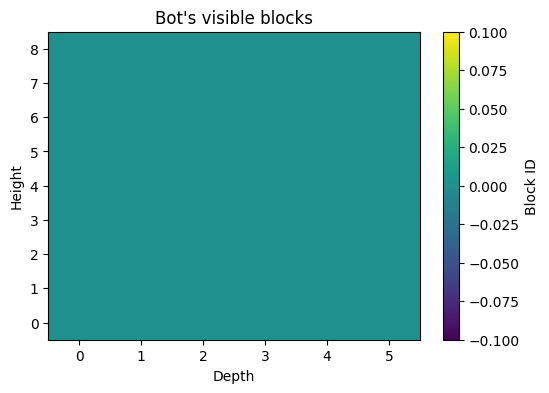

Testing forward movement and jump...
Applying action 0: [1, 0, 0, 0, 0, 0, 0, 0]
Bot pos: Vec3 { x: 10.7, y: -60, z: -12.7 }
Reward: -1 Terminated: False Truncated: False
Block matrix (IDs):
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
Applying action 1: [0, 0, 0, 0, 1, 0, 0, 0]
Bot pos: Vec3 { x: 8.5, y: -55, z: 12.5 }
Reward: -1 Terminated: False Truncated: False
Block matrix (IDs):
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
Applying action 2: [1, 0, 0, 0, 1, 0, 0, 0]
Bot pos: Vec3 {
  x: 8.969168221614682,
  y: -55.504799122994086,
  z: 11.46274148397036
}
Reward: 1 Terminated: False Truncated: False
Block matrix (IDs):
[[  0  93   0   0   0   0]
 [  0  93   0   0   0   0]
 [163  93   0   0   0   0]
 [  0  93   0   0   0   0]
 [  0  93   0   0   0   0]
 [  0  93   0   0   0   0]
 [  0   0   0   0   0  

In [15]:
# 1. Instantiate your environment (do this after the bot is created and connected)
env = MinecraftRL(jump_id=0)  # or jump_id=1 for Jump2

# 2. Teleport to start and print position
print("Teleporting to start position...")
env.teleport_to_start()
#time.sleep(2)  # Wait for teleport to process

pos = env.bot.entity.position
print(f"Bot position: ({pos.x:.2f}, {pos.y:.2f}, {pos.z:.2f})")

# 3. Test observations: get and display the block matrix
obs = env.get_visible_blocks()
print("Observation matrix shape:", obs.shape)
print("Block matrix (IDs):")
print(obs)

# Optional: Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.imshow(obs, origin='lower', aspect='auto')
plt.colorbar(label='Block ID')
plt.title("Bot's visible blocks")
plt.xlabel('Depth')
plt.ylabel('Height')
plt.show()

# 4. Test action execution: try moving forward & jumping
print("Testing forward movement and jump...")

# Format: [fwd, back, left, right, jump, sprint, turnL, turnR]
move_forward = [1,0,0,0,0,0,0,0]
jump_only   = [0,0,0,0,1,0,0,0]
jump_forward = [1,0,0,0,1,0,0,0]
turn_right = [0,0,0,0,0,0,0,1]

# Do one action at a time
for i, action in enumerate([move_forward, jump_only, jump_forward]):
    print(f"Applying action {i}: {action}")
    obs2, reward, terminated, truncated, info = env.step(action)
    print("Bot pos:", env.bot.entity.position)
    print("Reward:", reward, "Terminated:", terminated, "Truncated:", truncated)
    print("Block matrix (IDs):")
    print(obs2)
    time.sleep(2)  # Wait so you can observe in Minecraft if you want

print("All tests completed.")


In [16]:
import time
print("Moving forward for 2 seconds...")
bot.setControlState('forward', True)
time.sleep(2)
bot.setControlState('forward', False)
print("Did the bot move?")


Moving forward for 2 seconds...
Did the bot move?


## 📦 Wrapping with Stable-Baselines3  
Explain how to instantiate an RL agent:  
- Choose PPO (or DQN)  
- Pass your `MinecraftRL` env into the model  


In [17]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_util import make_vec_env

log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)
# Make a non-vectorized env (or set n_envs=1)
monitored_env = Monitor(MinecraftRL(), log_dir)

model = PPO("MlpPolicy", monitored_env, verbose=1, n_steps=2048)


Using cpu device
Wrapping the env in a DummyVecEnv.


In [18]:
# Manually move bot onto an obsidian block first, or teleport him there:
# Example (replace x, y, z with obsidian's position)
env.bot.chat("/tp 8 -58 2")  # TP to an obsidian block
time.sleep(1)  # Give time for teleport

# Now test reward logic:
obs, reward, terminated, truncated, info = env.step([0,0,0,0,0,0,0,0])
print("Test: Agent on obsidian block")
print("Reward:", reward, "Terminated:", terminated, "Truncated:", truncated)

if terminated and reward == -100:
    print("✅ Death detected correctly!")
else:
    print("❌ Death not detected. Check detection logic or block placement.")


Test: Agent on obsidian block
Reward: -100 Terminated: True Truncated: False
✅ Death detected correctly!


## 🚂 Training Loop  
Describe running `model.learn`:  
- Total timesteps or episodes  
- Where you log rewards/metrics  

In [19]:
from stable_baselines3.common.callbacks import CheckpointCallback

# save every 10k steps
checkpoint_cb = CheckpointCallback(save_freq=10_000, save_path=log_dir, name_prefix="ppo_mc")
model.learn(total_timesteps=200_000, callback=checkpoint_cb)


KeyboardInterrupt: 

## 📈 Training Logs & Plots  
Show how to load or collect your training logs and plot the learning curve:  
- Use Matplotlib to plot episode returns over time  


In [ ]:
import pandas as pd

df = pd.read_csv(os.path.join(log_dir, "monitor.csv"), skiprows=1)
# rolling mean of reward
df['r_mean'] = df['r'].rolling(10).mean()

plt.figure()
plt.plot(df['r_mean'])
plt.xlabel("Episode")
plt.ylabel("Rolling Mean Reward")
plt.show()


## 🧪 Evaluation & Demo Episodes  
Roll out a few episodes under the trained policy:  
- Reset env, step with `model.predict`  
- Use your visualization helpers to display agent behavior  


In [ ]:
from stable_baselines3.common.evaluation import evaluate_policy

# Automated eval
mean_reward, std_reward = evaluate_policy(model, monitored_env, n_eval_episodes=5)
print(f"Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

# Manual demo
for ep in range(3):
    obs = monitored_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _ = monitored_env.step(action)
        render_agent_view(monitored_env)


## 🛠 Hyperparameter Tuning Tips  
List important hyperparameters to experiment with:  
- Learning rate, gamma, clip range, batch size, etc.  
- Suggest grid-search or Bayesian tuning approaches  


In [ ]:
param_grid = {
    'learning_rate': [1e-4, 3e-4, 1e-3],
    'gamma': [0.95, 0.99, 0.999],
    'n_steps': [128, 256, 512],
}
print("Example grid:", param_grid)


## 🔚 Conclusion & Next Steps  
Summarize results and propose extensions:  
- Continuous yaw control  
- Curriculum learning on progressively harder course  
- Integration with more complex objectives like doing courses using different mechanics like using a ladder on the side of a block, having an obstacle moving on a jump trajectory and more complex blocks arrangments needing to guess the good way when there are many possible next jump choice possible.

In [ ]:
bot.quit()